#Building a SimpleRNN Model for Weather Temperature Prediction

PART A : Data Understanding and Preprocessing

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [36]:
# 1. Load and Explore

df = pd.read_csv('weatherHistory.csv')

# Initial inspection
print("First 10 rows:")
print(df.head(10))
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

First 10 rows:
                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   
5  2006-04-01 05:00:00.000 +0200  Partly Cloudy        rain         9.222222   
6  2006-04-01 06:00:00.000 +0200  Partly Cloudy        rain         7.733333   
7  2006-04-01 07:00:00.000 +0200  Partly Cloudy        rain         8.772222   
8  2006-04-01 08:00:00.000 +0200  Partly Cloudy        rain        10.822222   
9  2006-04-01 09:00:00.000 +0200  Partly Cloudy        rain        13.772222   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89       

In [37]:
# Convert date and handle hourly to daily conversion
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df.set_index('Formatted Date', inplace=True)

# Resample to Daily Mean (Aggregating hourly data into daily averages)
df_daily = df[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']].resample('D').mean()

In [38]:
# Check for missing values and handle them
print("Missing values before cleaning:\n", df_daily.isnull().sum())
df_daily = df_daily.ffill() # Forward fill any missing days

# Display first 10 rows
print("\nFirst 10 rows of processed daily data:")
print(df_daily.head(10))

Missing values before cleaning:
 Temperature (C)      0
Humidity             0
Wind Speed (km/h)    0
dtype: int64

First 10 rows of processed daily data:
                           Temperature (C)  Humidity  Wind Speed (km/h)
Formatted Date                                                         
2005-12-31 00:00:00+00:00         0.577778  0.890000          17.114300
2006-01-01 00:00:00+00:00         4.075000  0.817083          21.229192
2006-01-02 00:00:00+00:00         5.263194  0.847083          17.824713
2006-01-03 00:00:00+00:00         2.340509  0.897083           7.726658
2006-01-04 00:00:00+00:00         2.251852  0.906667          12.152817
2006-01-05 00:00:00+00:00         2.703935  0.951250           8.991179
2006-01-06 00:00:00+00:00         2.550463  0.945833           5.729588
2006-01-07 00:00:00+00:00         0.877083  0.935833           6.589596
2006-01-08 00:00:00+00:00        -1.231713  0.868750           5.397525
2006-01-09 00:00:00+00:00        -1.693287  0.792500 

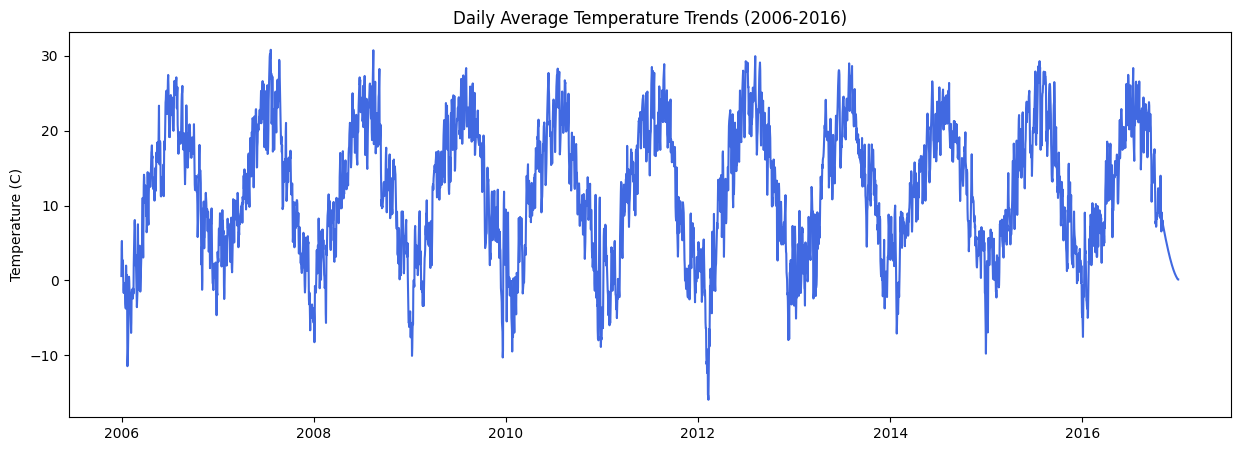

In [39]:
# Plot temperature trends
plt.figure(figsize=(15, 5))
plt.plot(df_daily['Temperature (C)'], color='royalblue')
plt.title('Daily Average Temperature Trends (2006-2016)')
plt.ylabel('Temperature (C)')
plt.show()

In [40]:
# 2. Preprocess and Sequence Creation
features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_daily[features])

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])    # Input: Past 7 days
        y.append(data[i + seq_length, 0])     # Target: Next day Temp
    return np.array(X), np.array(y)

SEQ_LENGTH = 7
X, y = create_sequences(scaled_data, SEQ_LENGTH)

In [41]:
# Split Dataset (70% Train, 15% Val, 15% Test)
train_end = int(len(X) * 0.7)
val_end = int(len(X) * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

PART B: RNN Model Development

In [42]:
 #Build, Compile, and Train
model = Sequential([
    SimpleRNN(64, input_shape=(SEQ_LENGTH, len(features)), activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1) # Linear activation for regression
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0202 - mae: 0.1079 - val_loss: 0.0043 - val_mae: 0.0535
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0085 - mae: 0.0734 - val_loss: 0.0046 - val_mae: 0.0555
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0067 - mae: 0.0650 - val_loss: 0.0030 - val_mae: 0.0433
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0054 - mae: 0.0579 - val_loss: 0.0037 - val_mae: 0.0494
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0053 - mae: 0.0585 - val_loss: 0.0057 - val_mae: 0.0638
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0045 - mae: 0.0535 - val_loss: 0.0024 - val_mae: 0.0384
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0043 - mae: 0.0518 - val_loss: 0.0032 - val_mae: 0.0459
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038 - mae: 0.0489 - val_loss: 0.0026 - val_mae: 0.0413
Epoch 9/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0041 - mae: 0.0507 - v

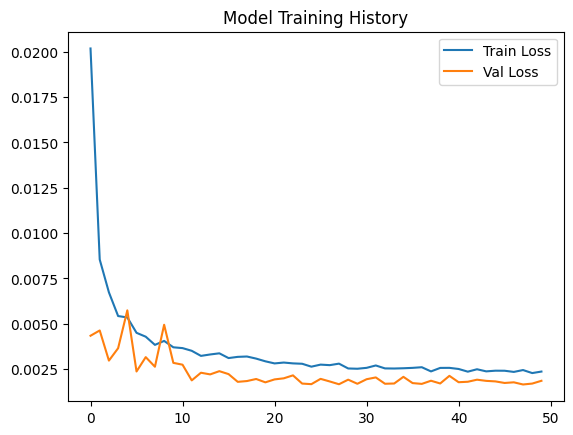

In [43]:
# Plot Training vs Validation Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Training History')
plt.legend()
plt.show()

PART C: Model Evaluation & Forecasting

In [44]:
#6. Evaluation
y_pred_scaled = model.predict(X_test)

# Inverse scaling helper
def get_inv_temp(scaled_vals):
    dummy = np.zeros((len(scaled_vals), len(features)))
    dummy[:, 0] = scaled_vals.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

inv_y_pred = get_inv_temp(y_pred_scaled)
inv_y_test = get_inv_temp(y_test)

print(f"\n--- Model Performance ---")
print(f"RMSE: {np.sqrt(mean_squared_error(inv_y_test, inv_y_pred)):.2f}")
print(f"MAE: {mean_absolute_error(inv_y_test, inv_y_pred):.2f}")
print(f"R2 Score: {r2_score(inv_y_test, inv_y_pred):.2f}")


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

--- Model Performance ---
RMSE: 2.11
MAE: 1.66
R2 Score: 0.94


In [45]:
#7. Forecast next 7 days
last_window = scaled_data[-SEQ_LENGTH:].tolist()
future_preds = []

for _ in range(7):
    curr_input = np.array(last_window[-SEQ_LENGTH:]).reshape(1, SEQ_LENGTH, len(features))
    next_temp = model.predict(curr_input)[0,0]
    future_preds.append(next_temp)
    # Using last known humidity and wind speed for the recursive step
    last_window.append([next_temp, last_window[-1][1], last_window[-1][2]])

final_forecast = get_inv_temp(np.array(future_preds))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


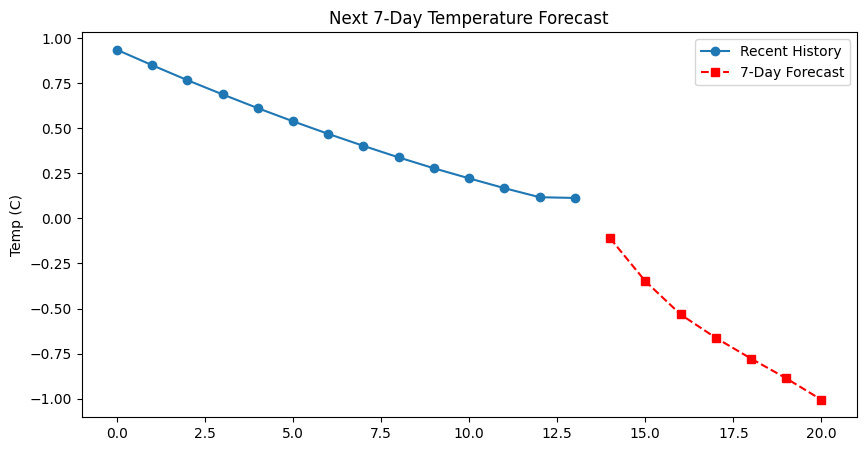

In [46]:
#Visualize Forecast vs Recent Data
plt.figure(figsize=(10, 5))
plt.plot(range(14), inv_y_test[-14:], label='Recent History', marker='o')
plt.plot(range(14, 21), final_forecast, label='7-Day Forecast', linestyle='--', marker='s', color='red')
plt.title('Next 7-Day Temperature Forecast')
plt.ylabel('Temp (C)')
plt.legend()
plt.show()